# Information Retrieval: Siswa Berprestasi SMA/SMP Indonesia

**Tujuan:** Mengumpulkan basis data siswa berprestasi (akademik & non-akademik) tingkat SMA/SMP di seluruh Indonesia  
**Target:** Siswa kelas XI tahun 2026  
**Sumber:** Instagram (hashtag), berita online  
**Tools:** Apify (Instagram Hashtag Scraper + Web Scraper)  
**Manfaat:** Membantu perguruan tinggi seleksi calon mahasiswa di luar jalur SNBP

---
⚠️ *Pastikan kamu memiliki API token Apify yang valid di [apify.com](https://apify.com)*

## 1. Install Dependencies

In [ ]:
!pip3 install apify-client pandas openpyxl tqdm matplotlib seaborn

## 2. Konfigurasi

In [ ]:
from apify_client import ApifyClient
import pandas as pd
import re
import json
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# API token Apify
APIFY_TOKEN = "apify_api_bbcrW0I6FpEWrcSov2CiyyfAF5CyrN2T2ckj"

# Batas hasil per hashtag
RESULTS_PER_HASHTAG = 50

# Hanya ambil postingan mulai tahun 2025 (relevan kelas XI 2026)
SINCE_DATE = "2025-01-01"

# Hashtag Instagram yang akan di-scrape
HASHTAGS = [
    # === Akademik: Olimpiade & Kompetisi Sains ===
    "osn2026", "osn2025",
    "osnkabupaten2026", "osnprovinsi2026",
    "ksnk2026", "ksnp2026",
    "olimpiadematematika", "olimpiadesains",
    "olimpiadafisika", "olimpiadakimia",
    "olimpiadabiologi", "olimpiadainformatika",
    "olimpiadaastronomisma",
    # === Non-Akademik: Olahraga & Seni ===
    "o2sn2026", "o2sn2025",
    "fls2n2026", "fls2n2025",
    "juaraolahragasma", "juaraolahragasmp",
    "juarasenibudaya",
    # === Umum Prestasi Siswa ===
    "siswaberprestasi", "siswaberprestasi2026",
    "siswaberprestasisma", "siswaberprestasiSMP",
    "juarasiswa", "juaranasional2026",
    "juaraprovinsi2026", "juaranasional",
    "siswaberprestasinasional",
    "kelasXI2026", "kelasxi2026",
    "bangga_jadi_guru",
    # === Karya Ilmiah & Debat ===
    "karyailmiahremaja", "kir2026",
    "debatsma", "debatsmp",
]

# Keyword filter kelas XI
KELAS_XI_KEYWORDS = [
    "kelas xi", "kelas 11", "grade 11", "xi ipa", "xi ips",
    "xi mia", "xi iis", "angkatan 2025", "angkatan 2026",
    "tahun 2026",
]

print(f"Total hashtag  : {len(HASHTAGS)}")
print(f"Scraping sejak : {SINCE_DATE}")
print(f"Estimasi maks  : {len(HASHTAGS) * RESULTS_PER_HASHTAG} postingan")

## 3. Scraping Instagram per Hashtag

In [ ]:
client = ApifyClient(APIFY_TOKEN)
all_posts = []
failed_hashtags = []

for hashtag in tqdm(HASHTAGS, desc="Scraping hashtag"):
    try:
        run_input = {
            "hashtags": [hashtag],
            "resultsLimit": RESULTS_PER_HASHTAG,
            "onlyPostsNewerThan": SINCE_DATE,
        }
        run = client.actor("reGe1ST3OBgYZSsZJ").call(run_input=run_input)
        count = 0
        for item in client.dataset(run["defaultDatasetId"]).iterate_items():
            item["_sumber"] = "instagram"
            item["_scraped_hashtag"] = hashtag
            all_posts.append(item)
            count += 1
        print(f"  ✅ #{hashtag}: {count} postingan")
    except Exception as e:
        failed_hashtags.append(hashtag)
        print(f"  ❌ #{hashtag}: {e}")

print(f"\n📊 Total postingan terkumpul : {len(all_posts)}")
if failed_hashtags:
    print(f"⚠️  Hashtag gagal ({len(failed_hashtags)}): {failed_hashtags}")

## 4. Scraping Berita Online (Google News)

Sumber sekunder untuk validasi — berita dari media nasional lebih kredibel untuk perguruan tinggi.

In [26]:
NEWS_QUERIES = [
    "siswa SMA juara nasional 2026",
    "siswa SMP juara olimpiade 2026",
    "juara OSN 2026 SMA",
    "juara O2SN 2026",
    "juara FLS2N 2026",
    "siswa berprestasi internasional 2026",
]

all_news = []

for query in tqdm(NEWS_QUERIES, desc="Scraping berita"):
    try:
        run_input = {
            "queries": query,
            "maxResultsPerQuery": 20,
            "includeUnfilteredResults": False,
            "languageCode": "id",
            "countryCode": "id",
        }
        # Apify: Google Search Scraper
        run = client.actor("nFJndFXA5zjCTuudP").call(run_input=run_input)
        count = 0
        for item in client.dataset(run["defaultDatasetId"]).iterate_items():
            item["_sumber"] = "berita"
            item["_query"] = query
            all_news.append(item)
            count += 1
        print(f"  ✅ '{query}': {count} hasil")
    except Exception as e:
        print(f"  ❌ '{query}': {e}")

print(f"\n📰 Total berita terkumpul: {len(all_news)}")

Scraping berita:   0%|          | 0/6 [00:00<?, ?it/s][apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> Status: RUNNING, Message: 
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:08.781Z ACTOR: Pulling container image of build zxhtb9D2Em3SAjYz7 from registry.
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:08.784Z ACTOR: Creating container.
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:08.833Z ACTOR: Starting container.
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:08.833Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:09.175Z Running on architecture: x86_64
[apify.google-search-scraper runId:NZpY7yW60ZL4t2Ylc] -> 2026-05-07T13:02:09.175Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefail -c node dist/src/main.js
[apify.google-search-scr

  ✅ 'siswa SMA juara nasional 2026': 1 hasil


[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> Status: RUNNING, Message: 
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> Status: RUNNING, Message: Starting the crawler.
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:21.690Z ACTOR: Pulling container image of build zxhtb9D2Em3SAjYz7 from registry.
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:21.692Z ACTOR: Creating container.
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:21.806Z ACTOR: Starting container.
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:21.808Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:22.075Z Running on architecture: x86_64
[apify.google-search-scraper runId:Hyrp9gv8Aq5dfv3L1] -> 2026-05-07T13:02:22.077Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefai

  ✅ 'siswa SMP juara olimpiade 2026': 1 hasil


[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> Status: RUNNING, Message: 
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.589Z ACTOR: Pulling container image of build zxhtb9D2Em3SAjYz7 from registry.
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.590Z ACTOR: Creating container.
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.620Z ACTOR: Starting container.
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.621Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.813Z Running on architecture: x86_64
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:37.814Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefail -c node dist/src/main.js
[apify.google-search-scraper runId:NjVL6hkpxmfhJCrTm] -> 2026-05-07T13:02:38.3

...

  ✅ 'juara O2SN 2026': 1 hasil


[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> Status: RUNNING, Message: 
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> Status: RUNNING, Message: Starting the crawler.
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.146Z ACTOR: Pulling container image of build zxhtb9D2Em3SAjYz7 from registry.
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.148Z ACTOR: Creating container.
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.189Z ACTOR: Starting container.
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.191Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.431Z Running on architecture: x86_64
[apify.google-search-scraper runId:36998qHX7aWjlDBJE] -> 2026-05-07T13:03:33.433Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefai

  ✅ 'juara FLS2N 2026': 1 hasil


[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> Status: RUNNING, Message: 
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> Status: RUNNING, Message: Starting the crawler.
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.286Z ACTOR: Pulling container image of build zxhtb9D2Em3SAjYz7 from registry.
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.289Z ACTOR: Creating container.
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.338Z ACTOR: Starting container.
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.339Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.606Z Running on architecture: x86_64
[apify.google-search-scraper runId:1DWZDVXwY1WyyaUE7] -> 2026-05-07T13:03:56.609Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefai

  ✅ 'siswa berprestasi internasional 2026': 1 hasil

📰 Total berita terkumpul: 6


## 5. Ekstraksi Entitas & Data Terstruktur

In [27]:
# Sekolah: pola spesifik (prefix + nomor/nama), hindari menangkap kalimat bebas
SEKOLAH_PATTERN = re.compile(
    r'\b((?:SMAN?|SMPN?|SMKN?|MAN|MTs)\s*\d+(?:\s+[A-Za-z][A-Za-z\s]{0,20})?'
    r'|(?:SMA|SMK|SMP|MAN|MTs)\s+(?:Negeri|Swasta|IT|Islam|Al|Plus|PKP|[A-Z][A-Za-z]{2,15})(?:\s+\d+)?(?:\s+[A-Z][A-Za-z\s]{0,15})?)'
    r'\b',
    re.IGNORECASE
)

# Hashtag sekolah: #sman7yogyakarta -> 'SMAN 7'
HASHTAG_SEKOLAH = re.compile(r'#((?:sman|smpn|smkn|sma|smp|smk|man)\w+)', re.IGNORECASE)

# Kata yang bukan nama siswa (false positive)
_BUKAN_NAMA = {'para', 'ananda', 'peserta', 'penerima', 'siswa', 'pelajar',
               'selamat', 'sukses', 'prestasi', 'keluarga', 'semua', 'seluruh'}

_STOP = r'(?=\s+(?:atas|yang|telah|dalam|meraih|dari|dan|berhasil|sebagai|pada|di\b|kelas|IG))'

# Nama siswa: beberapa pola dengan prioritas
NAMA_PATTERNS = [
    # Pola 1: 'Ananda/kepada ananda/untuk ananda' + nama (hentikan di stop word)
    re.compile(r'(?i)(?:ananda|kepada\s+ananda|untuk\s+ananda)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 2: 'selamat kepada' + nama (hentikan di stop word)
    re.compile(r'(?i)(?:selamat\s+(?:dan\s+)?(?:sukses\s+)?kepada)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 3: nama di depan '(XI-N)' - paling akurat untuk kelas XI
    re.compile(r'(?:kepada|untuk)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,4})\s*\(XI[-\s]?\d+\)'),
    # Pola 4: nama ALL CAPS di baris sendiri setelah 'untuk\n'
    re.compile(r'(?:untuk|sukses untuk)\s*\n\s*([A-Z]{2}[A-Z ]{3,38}?)(?:\n)', re.MULTILINE),
    # Pola 5: congratulations to + nama
    re.compile(r'(?i)congratulations?\s+to\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 6: fallback 'ananda' tanpa stop word
    re.compile(r'(?i)(?:ananda)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})'),
]

def _bersih_nama(nama):
    """Bersihkan trailing kata umum dari hasil regex nama."""
    nama = re.sub(r'\s+(?:atas|yang|telah|dalam|meraih|berhasil|dari|kelas|IG|dan)\b.*$', '', nama, flags=re.IGNORECASE).strip()
    first = nama.split()[0].lower() if nama else ''
    if first in _BUKAN_NAMA or len(nama) < 4:
        return None
    return nama.title() if nama.isupper() else nama

def ekstrak_nama_siswa(caption):
    for pat in NAMA_PATTERNS:
        hasil = pat.findall(caption)
        if hasil:
            nama = _bersih_nama(hasil[0].strip() if isinstance(hasil[0], str) else hasil[0].strip())
            if nama:
                return nama
    return None

def ekstrak_sekolah(caption, akun_poster=''):
    # Coba dari teks caption
    m = SEKOLAH_PATTERN.findall(caption)
    if m:
        return m[0].strip()
    # Coba dari hashtag (#sman7yogyakarta -> 'SMAN 7')
    hm = HASHTAG_SEKOLAH.findall(caption)
    if hm:
        # Pilih hashtag yang mengandung angka (lebih spesifik) atau terpanjang
        hm_sorted = sorted(hm, key=lambda x: (bool(re.search(r'\d', x)), len(x)), reverse=True)
        for htag in hm_sorted:
            raw = htag.lower()
            for prefix in ['sman', 'smpn', 'smkn', 'sma', 'smp', 'smk', 'man']:
                if raw.startswith(prefix):
                    rest = raw[len(prefix):]
                    num = re.match(r'(\d+)', rest)
                    return prefix.upper() + (' ' + num.group(1) if num else ' ' + rest.title())
    # Coba dari nama akun poster
    if akun_poster:
        m2 = SEKOLAH_PATTERN.findall(str(akun_poster))
        if m2:
            return m2[0].strip()
    return None

PROVINSI_LIST = [
    "aceh", "sumatera utara", "sumut", "sumatera barat", "sumbar", "riau",
    "kepulauan riau", "jambi", "sumatera selatan", "sumsel", "bengkulu",
    "lampung", "bangka belitung", "babel", "dki jakarta", "jakarta",
    "jawa barat", "jabar", "jawa tengah", "jateng", "di yogyakarta",
    "yogyakarta", "jogja", "jawa timur", "jatim", "banten", "bali",
    "nusa tenggara barat", "ntb", "nusa tenggara timur", "ntt",
    "kalimantan barat", "kalbar", "kalimantan tengah", "kalteng",
    "kalimantan selatan", "kalsel", "kalimantan timur", "kaltim",
    "kalimantan utara", "kalut", "sulawesi utara", "sulut",
    "sulawesi tengah", "sulteng", "sulawesi selatan", "sulsel",
    "sulawesi tenggara", "sultra", "gorontalo", "sulawesi barat", "sulbar",
    "maluku", "maluku utara", "papua", "papua barat", "papua selatan",
    "papua tengah", "papua pegunungan", "papua barat daya",
]

TINGKAT_KEYWORDS = {
    "Internasional": ["internasional", "international", "world", "imo", "ibo", "icho", "apho", "apio"],
    "Nasional"     : ["nasional", "national", "osn", "o2sn", "fls2n", "ksnk", "ksnp", "tingkat nasional"],
    "Provinsi"     : ["provinsi", "provincial", "tingkat provinsi", "tingkat prov"],
    "Kota/Kabupaten": ["kota", "kabupaten", "tingkat kota", "tingkat kab"],
}

BIDANG_KEYWORDS = {
    "Akademik - Matematika"  : ["matematika", "math", "olimpiade mat", "osn mat"],
    "Akademik - Fisika"      : ["fisika", "physics", "osn fis"],
    "Akademik - Kimia"       : ["kimia", "chemistry", "osn kim"],
    "Akademik - Biologi"     : ["biologi", "biology", "osn bio"],
    "Akademik - Informatika" : ["informatika", "komputer", "programming", "coding", "osn inf"],
    "Akademik - Ekonomi"     : ["ekonomi", "economics", "osn eko"],
    "Akademik - Astronomi"   : ["astronomi", "astronomy", "osn astro"],
    "Akademik - Kebumian"    : ["kebumian", "geoscience"],
    "Olahraga"               : ["olahraga", "o2sn", "basket", "voli", "renang", "atletik",
                                 "silat", "karate", "taekwondo", "bulutangkis", "sepak bola"],
    "Seni & Budaya"          : ["seni", "fls2n", "tari", "musik", "vokal", "vocal",
                                 "menyanyi", "lukis", "kriya", "teater", "baca puisi"],
    "Debat"                  : ["debat", "debate"],
    "Karya Ilmiah"           : ["kir", "karya ilmiah", "penelitian", "research", "lkir"],
}

JUARA_PATTERN = re.compile(
    r'(?:juara|peringkat|medali|gold|silver|bronze|emas|perak|perunggu)[\s\w]*(?:1|2|3|i{1,3}|pertama|kedua|ketiga)?',
    re.IGNORECASE
)

def ekstrak_provinsi(text):
    text_lower = text.lower()
    for prov in PROVINSI_LIST:
        if prov in text_lower:
            return prov.title()
    return None

def cek_kelas_xi(text):
    text_lower = text.lower()
    return any(kw in text_lower for kw in KELAS_XI_KEYWORDS)

def ekstrak_informasi(caption):
    if not caption:
        return {}
    caption_lower = caption.lower()
    result = {}

    result["sekolah"] = ekstrak_sekolah(caption)

    result["nama_siswa"] = ekstrak_nama_siswa(caption)

    result["provinsi"] = ekstrak_provinsi(caption)
    result["is_kelas_xi"] = cek_kelas_xi(caption)

    result["tingkat_kompetisi"] = None
    for tingkat, keywords in TINGKAT_KEYWORDS.items():
        if any(kw in caption_lower for kw in keywords):
            result["tingkat_kompetisi"] = tingkat
            break

    result["bidang_prestasi"] = None
    for bidang, keywords in BIDANG_KEYWORDS.items():
        if any(kw in caption_lower for kw in keywords):
            result["bidang_prestasi"] = bidang
            break

    juara_match = JUARA_PATTERN.findall(caption)
    result["info_juara"] = juara_match[0].strip() if juara_match else None

    return result

def parse_postingan(post):
    caption = post.get("caption", "") or ""
    ekstrak = ekstrak_informasi(caption)
    return {
        "post_id"           : post.get("id"),
        "url"               : post.get("url"),
        "tanggal_post"      : post.get("timestamp"),
        "username_poster"   : post.get("ownerUsername"),
        "nama_akun_poster"  : post.get("ownerFullName"),
        "likes"             : post.get("likesCount", 0),
        "komentar"          : post.get("commentsCount", 0),
        "sumber"            : post.get("_sumber", "instagram"),
        "hashtag_sumber"    : post.get("_scraped_hashtag"),
        "caption"           : caption[:500],
        "nama_siswa"        : ekstrak.get("nama_siswa"),
        "sekolah"           : ekstrak.get("sekolah") or ekstrak_sekolah(caption, post.get("ownerFullName", "") or ""),
        "provinsi"          : ekstrak.get("provinsi"),
        "is_kelas_xi"       : ekstrak.get("is_kelas_xi", False),
        "tingkat_kompetisi" : ekstrak.get("tingkat_kompetisi"),
        "bidang_prestasi"   : ekstrak.get("bidang_prestasi"),
        "info_juara"        : ekstrak.get("info_juara"),
    }

def parse_berita(item):
    teks = (item.get("title", "") or "") + " " + (item.get("description", "") or "")
    ekstrak = ekstrak_informasi(teks)
    return {
        "post_id"           : item.get("url"),
        "url"               : item.get("url"),
        "tanggal_post"      : item.get("date"),
        "username_poster"   : item.get("displayedUrl"),
        "nama_akun_poster"  : item.get("displayedUrl"),
        "likes"             : 0,
        "komentar"          : 0,
        "sumber"            : "berita",
        "hashtag_sumber"    : item.get("_query"),
        "caption"           : teks[:500],
        "nama_siswa"        : ekstrak.get("nama_siswa"),
        "sekolah"           : ekstrak.get("sekolah") or ekstrak_sekolah(caption, post.get("ownerFullName", "") or ""),
        "provinsi"          : ekstrak.get("provinsi"),
        "is_kelas_xi"       : ekstrak.get("is_kelas_xi", False),
        "tingkat_kompetisi" : ekstrak.get("tingkat_kompetisi"),
        "bidang_prestasi"   : ekstrak.get("bidang_prestasi"),
        "info_juara"        : ekstrak.get("info_juara"),
    }

parsed_ig   = [parse_postingan(p) for p in all_posts]
parsed_news = [parse_berita(n) for n in all_news]
all_parsed  = parsed_ig + parsed_news

df = pd.DataFrame(all_parsed)
df.drop_duplicates(subset="post_id", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Total data unik          : {len(df)}")
print(f"   - Dari Instagram         : {len(parsed_ig)}")
print(f"   - Dari berita online     : {len(parsed_news)}")
print(f"   - Terdeteksi kelas XI    : {df['is_kelas_xi'].sum()}")
df.head()

NameError: name 'caption' is not defined

## 6. Filter & Deduplikasi Lanjutan

In [22]:
df_prestasi = df[
    df["bidang_prestasi"].notna() |
    df["tingkat_kompetisi"].notna() |
    df["info_juara"].notna()
].copy()

# Deduplikasi lanjutan: siswa + sekolah + bidang yang sama
dedup_cols = ["nama_siswa", "sekolah", "bidang_prestasi"]
has_all = df_prestasi[dedup_cols].notna().all(axis=1)
df_dedup = df_prestasi[has_all].drop_duplicates(subset=dedup_cols)
df_no_dedup = df_prestasi[~has_all]
df_prestasi = pd.concat([df_dedup, df_no_dedup]).reset_index(drop=True)

print(f"Postingan relevan         : {len(df_prestasi)} dari {len(df)} total")
print(f"\n📊 Bidang Prestasi:")
print(df_prestasi["bidang_prestasi"].value_counts().to_string())
print(f"\n🏆 Tingkat Kompetisi:")
print(df_prestasi["tingkat_kompetisi"].value_counts().to_string())
print(f"\n🗺️  Top 10 Provinsi:")
print(df_prestasi["provinsi"].value_counts().head(10).to_string())

Postingan relevan         : 411 dari 438 total

📊 Bidang Prestasi:
bidang_prestasi
Akademik - Matematika     86
Olahraga                  79
Seni & Budaya             78
Karya Ilmiah              48
Debat                     27
Akademik - Ekonomi         4
Akademik - Informatika     3
Akademik - Biologi         3
Akademik - Fisika          2

🏆 Tingkat Kompetisi:
tingkat_kompetisi
Nasional          294
Internasional       9
Kota/Kabupaten      8
Provinsi            1

🗺️  Top 10 Provinsi:
provinsi
Bali                 23
Jakarta              20
Yogyakarta            7
Sulawesi Selatan      6
Lampung               5
Banten                4
Jawa Timur            3
Aceh                  2
Di Yogyakarta         2
Kalimantan Tengah     2


## 7. Visualisasi Data

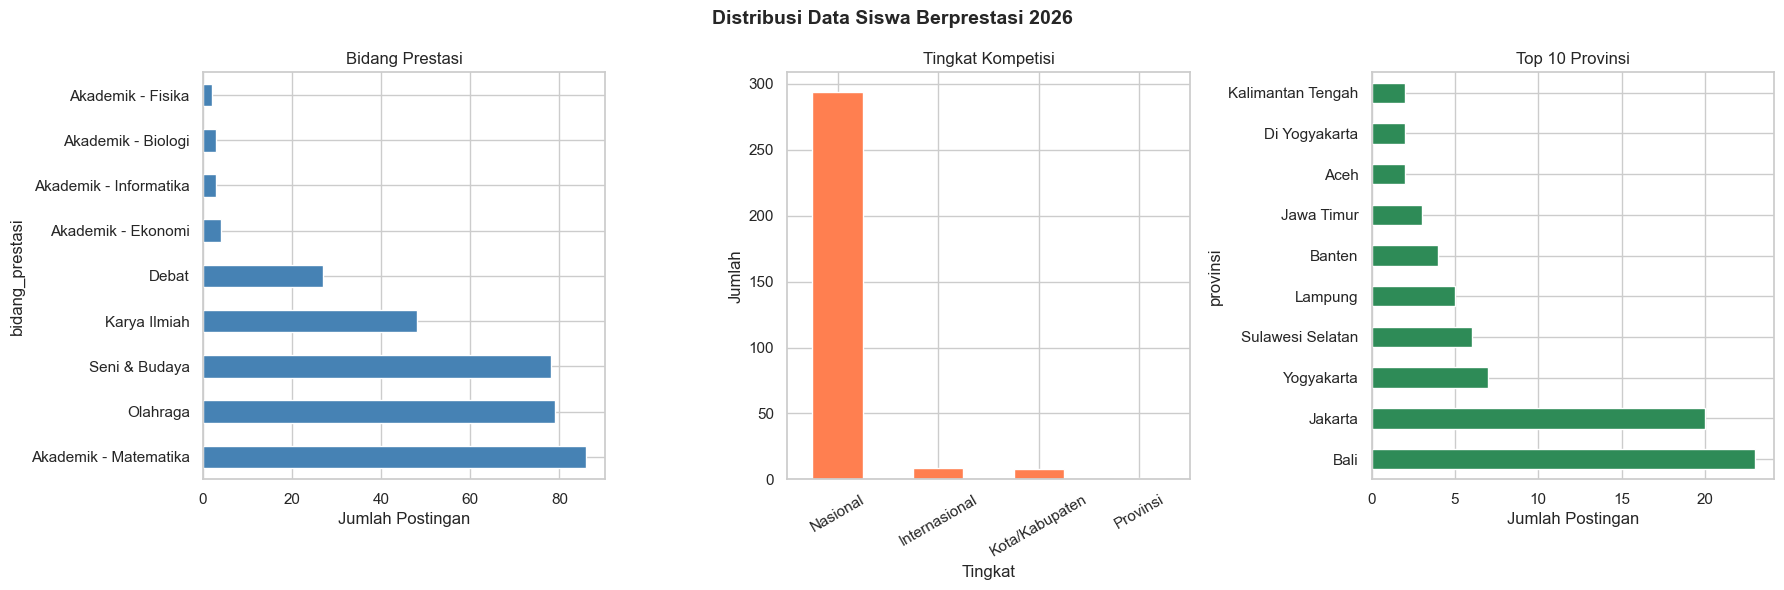

✅ Visualisasi disimpan: visualisasi_siswa_berprestasi.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribusi Data Siswa Berprestasi 2026", fontsize=14, fontweight="bold")

# Chart 1: Bidang Prestasi
bidang_counts = df_prestasi["bidang_prestasi"].value_counts()
if not bidang_counts.empty:
    bidang_counts.plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Bidang Prestasi")
    axes[0].set_xlabel("Jumlah Postingan")

# Chart 2: Tingkat Kompetisi
tingkat_counts = df_prestasi["tingkat_kompetisi"].value_counts()
if not tingkat_counts.empty:
    tingkat_counts.plot(kind="bar", ax=axes[1], color="coral", rot=30)
    axes[1].set_title("Tingkat Kompetisi")
    axes[1].set_xlabel("Tingkat")
    axes[1].set_ylabel("Jumlah")

# Chart 3: Top 10 Provinsi
prov_counts = df_prestasi["provinsi"].value_counts().head(10)
if not prov_counts.empty:
    prov_counts.plot(kind="barh", ax=axes[2], color="seagreen")
    axes[2].set_title("Top 10 Provinsi")
    axes[2].set_xlabel("Jumlah Postingan")

plt.tight_layout()
plt.savefig("visualisasi_siswa_berprestasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi disimpan: visualisasi_siswa_berprestasi.png")

## 8. Simpan Data

In [24]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

df.to_csv(f"data_instagram_all_{timestamp}.csv", index=False, encoding="utf-8-sig")
print(f"✅ CSV semua data          : data_instagram_all_{timestamp}.csv")

df_prestasi.to_csv(f"data_siswa_berprestasi_{timestamp}.csv", index=False, encoding="utf-8-sig")
print(f"✅ CSV prestasi            : data_siswa_berprestasi_{timestamp}.csv")

with pd.ExcelWriter(f"data_siswa_berprestasi_{timestamp}.xlsx", engine="openpyxl") as writer:
    df_prestasi.to_excel(writer, sheet_name="Siswa Berprestasi", index=False)
    df_prestasi[df_prestasi["is_kelas_xi"]].to_excel(writer, sheet_name="Kelas XI 2026", index=False)
    df.to_excel(writer, sheet_name="Semua Data", index=False)
print(f"✅ Excel (3 sheet)         : data_siswa_berprestasi_{timestamp}.xlsx")

with open(f"raw_posts_{timestamp}.json", "w", encoding="utf-8") as f:
    json.dump(all_posts + all_news, f, ensure_ascii=False, indent=2, default=str)
print(f"✅ JSON backup             : raw_posts_{timestamp}.json")

✅ CSV semua data          : data_instagram_all_20260507_195924.csv
✅ CSV prestasi            : data_siswa_berprestasi_20260507_195924.csv
✅ Excel (3 sheet)         : data_siswa_berprestasi_20260507_195924.xlsx
✅ JSON backup             : raw_posts_20260507_195924.json


## 9. Ringkasan Akhir

In [25]:
print("=" * 55)
print("   RINGKASAN DATA SISWA BERPRESTASI SMA/SMP 2026")
print("=" * 55)
print(f"Total data di-scrape          : {len(df)}")
print(f"  - Instagram                 : {(df['sumber']=='instagram').sum()}")
print(f"  - Berita online             : {(df['sumber']=='berita').sum()}")
print(f"Postingan relevan prestasi    : {len(df_prestasi)}")
print(f"Terdeteksi kelas XI           : {df_prestasi['is_kelas_xi'].sum()}")
print(f"Nama siswa terdeteksi         : {df_prestasi['nama_siswa'].notna().sum()}")
print(f"Sekolah terdeteksi            : {df_prestasi['sekolah'].notna().sum()}")
print(f"Provinsi terdeteksi           : {df_prestasi['provinsi'].notna().sum()}")
print()

cols = ["url", "tanggal_post", "nama_siswa", "sekolah", "provinsi",
        "bidang_prestasi", "tingkat_kompetisi", "info_juara", "is_kelas_xi", "sumber"]
df_prestasi[cols].head(10)

   RINGKASAN DATA SISWA BERPRESTASI SMA/SMP 2026
Total data di-scrape          : 438
  - Instagram                 : 438
  - Berita online             : 0
Postingan relevan prestasi    : 411
Terdeteksi kelas XI           : 40
Nama siswa terdeteksi         : 29
Sekolah terdeteksi            : 203
Provinsi terdeteksi           : 88



,url,tanggal_post,nama_siswa,sekolah,provinsi,bidang_prestasi,tingkat_kompetisi,info_juara,is_kelas_xi,sumber
0,https://www.instagram.com/p/DYCCsmkkXWV/,2026-05-07T09:19:20.000Z,Fitria Bela Pitaloka,SMKN 1 Sooko Mojokerto,Jawa Timur,Olahraga,Nasional,Juara 1 Pencak Silat Putri dalam O2SN 2026,True,instagram
1,https://www.instagram.com/p/DX_xGPZGUjO/,2026-05-06T11:57:56.000Z,Rizky Aditia,SMA Muhammadiyah Pangandaran,None,Seni & Budaya,Nasional,Juara 2 Lomba Baca Puisi dalam ajang Festival ...,False,instagram
2,https://www.instagram.com/p/DQ6dr5XiTuN/,2025-11-11T10:52:21.000Z,Aura Akhadina,SMA SMP JOMBANG,None,Seni & Budaya,Nasional,Juara 1 Menulis Cerita Nasional dalam ajang Fe...,False,instagram
3,https://www.instagram.com/p/DYCVnAXmvZG/,2026-05-07T11:55:28.000Z,Aan Akjub,SMA NEGERI 1 CEMPAKA bangga,None,Olahraga,Nasional,Juara pada KEJUARAAN PENCAK SILAT OKU TIMUR CH...,False,instagram
4,https://www.instagram.com/p/DYCKph0ifsO/,2026-05-07T10:19:43.000Z,Raqilla Shannon Zaafarani,SMA PKP Jakarta Islamic,Jakarta,Seni & Budaya,None,Juara Harapan 1 Bidang Komik Digital pada ajan...,False,instagram
5,https://www.instagram.com/p/DYCGJewEWWy/,2026-05-07T09:40:21.000Z,Bintang Permata Hati,SMAN 7,Yogyakarta,Olahraga,None,JUARA 2,True,instagram
6,https://www.instagram.com/p/DYCFsFaEfdE/,2026-05-07T09:36:21.000Z,Azka Novan Firmansyah,SMAN 7,Yogyakarta,Olahraga,None,JUARA 3,True,instagram
7,https://www.instagram.com/p/DYCUSerAsxO/,2026-05-07T11:44:25.000Z,None,SMA Prestasi Prima sedang,None,Karya Ilmiah,Nasional,None,False,instagram
8,https://www.instagram.com/p/DYCTs8hD03h/,2026-05-07T11:38:48.000Z,None,None,None,None,Nasional,None,False,instagram
9,https://www.instagram.com/p/DYCTcvoAekw/,2026-05-07T11:36:35.000Z,None,SMAN 4 BANTAENG,Sulsel,None,Nasional,None,False,instagram
